In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sqlalchemy import create_engine
caminho_arquivo = '../data/simulacao_chuvas_deslizamentos_rj.csv'

# Carregando o arquivo para a memória
df = pd.read_csv(caminho_arquivo)

# Cinco primeiras linhas da tabela
display(df.head())

# MetaDados e estruturas
display(df.info())

,ano,mes,data,municipio,regiao_rj,populacao,chuva_mm,temperatura_media,ocorrencias_deslizamento,desalojados,obitos,nivel_risco,indice_solo,umidade
0,2015,1,2015-01-01,Rio de Janeiro,Metropolitana,4091571,189.1,24.8,6,64,0,Crítico,0.72,88.2
1,2015,1,2015-01-01,Niterói,Metropolitana,5475024,316.2,24.3,5,58,1,Alto,1.00,93.5
2,2015,1,2015-01-01,Nova Iguaçu,Baixada,2104552,205.3,25.5,10,108,0,Crítico,0.87,82.2
3,2015,1,2015-01-01,Petrópolis,Serrana,4207259,108.8,28.1,3,24,0,Alto,0.50,60.9
4,2015,1,2015-01-01,Teresópolis,Serrana,4424517,204.2,26.8,9,85,0,Crítico,0.68,65.0


<class 'pandas.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ano                       960 non-null    int64  
 1   mes                       960 non-null    int64  
 2   data                      960 non-null    str    
 3   municipio                 960 non-null    str    
 4   regiao_rj                 960 non-null    str    
 5   populacao                 960 non-null    int64  
 6   chuva_mm                  960 non-null    float64
 7   temperatura_media         960 non-null    float64
 8   ocorrencias_deslizamento  960 non-null    int64  
 9   desalojados               960 non-null    int64  
 10  obitos                    960 non-null    int64  
 11  nivel_risco               960 non-null    str    
 12  indice_solo               960 non-null    float64
 13  umidade                   960 non-null    float64
dtypes: float64(4), int64(

None

In [25]:
df['data'] = pd.to_datetime(df['data'])
print("--- Novos Tipos de Dados ---")
display(df[['data']].dtypes)

--- Novos Tipos de Dados ---


data    datetime64[us]
dtype: object

In [26]:
print("\n--- Contagem de Nulos ---")
display(df.isnull().sum())


--- Contagem de Nulos ---


ano                         0
mes                         0
data                        0
municipio                   0
regiao_rj                   0
populacao                   0
chuva_mm                    0
temperatura_media           0
ocorrencias_deslizamento    0
desalojados                 0
obitos                      0
nivel_risco                 0
indice_solo                 0
umidade                     0
dtype: int64

In [27]:
# Total de afetados ( Desalojados e Óbitos)
df['total_afetados'] = df['desalojados'] + df['obitos']

# Porcentagem da população afeatada
df['porcentagem_afetada'] = round(((df['total_afetados'] / df['populacao']) * 100), 5)

# True/False -> indica se o evento teve mortes
df['teve_obito'] = df['obitos'] > 0

# Exibindo um recorte apenas com as colunas novas para validarmos a lógica
display(df[['data', 'municipio', 'desalojados', 'obitos', 'total_afetados', 'teve_obito', 'porcentagem_afetada']].head(10))

,data,municipio,desalojados,obitos,total_afetados,teve_obito,porcentagem_afetada
0,2015-01-01,Rio de Janeiro,64,0,64,False,0.00156
1,2015-01-01,Niterói,58,1,59,True,0.00108
2,2015-01-01,Nova Iguaçu,108,0,108,False,0.00513
3,2015-01-01,Petrópolis,24,0,24,False,0.00057
4,2015-01-01,Teresópolis,85,0,85,False,0.00192
5,2015-01-01,Nova Friburgo,139,2,141,True,0.00871
6,2015-01-01,Angra dos Reis,45,0,45,False,0.00165
7,2015-01-01,Campos dos Goytacazes,40,0,40,False,0.00095
8,2015-02-01,Rio de Janeiro,66,1,67,True,0.00121
9,2015-02-01,Niterói,10,0,10,False,0.00030


## Ocorrências de Deslizamento ao Longo dos Meses

Este gráfico apresenta a distribuição das ocorrências de deslizamentos ao longo dos meses do ano.

O objetivo é identificar possíveis padrões sazonais e verificar se determinados períodos concentram maior quantidade de eventos.

A análise pode auxiliar órgãos de monitoramento e prevenção na identificação de períodos que exigem maior atenção, planejamento de recursos e emissão de alertas preventivos.

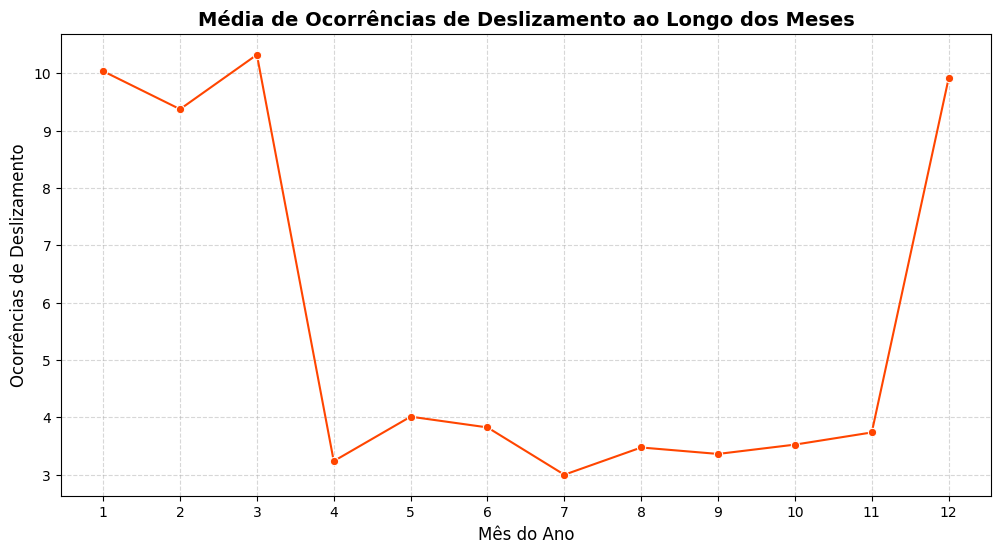

In [28]:


df['data'] = df['data'].dt.month
plt.figure(figsize=(12, 6))

sns.lineplot(x='mes', y='ocorrencias_deslizamento', data=df, marker='o', errorbar=None, color='#FF4500')
plt.title('Média de Ocorrências de Deslizamento ao Longo dos Meses', fontsize=14, fontweight='bold')
plt.xlabel('Mês do Ano', fontsize=12)
plt.ylabel('Ocorrências de Deslizamento', fontsize=12)
plt.xticks(range(1, 13)) # Força o eixo X a mostrar exatamente de 1 a 12
plt.grid(True, linestyle='--', alpha=0.5) # Adiciona uma grade de fundo

## Relação entre Precipitação e Ocorrências de Deslizamento

Este gráfico mostra a relação entre o volume de chuva registrado (em milímetros) e a quantidade de ocorrências de deslizamentos.

A análise permite observar se existe uma tendência de aumento dos deslizamentos conforme os índices pluviométricos crescem.

Esse tipo de informação é importante para apoiar sistemas de alerta e ações preventivas em áreas suscetíveis a movimentos de massa.

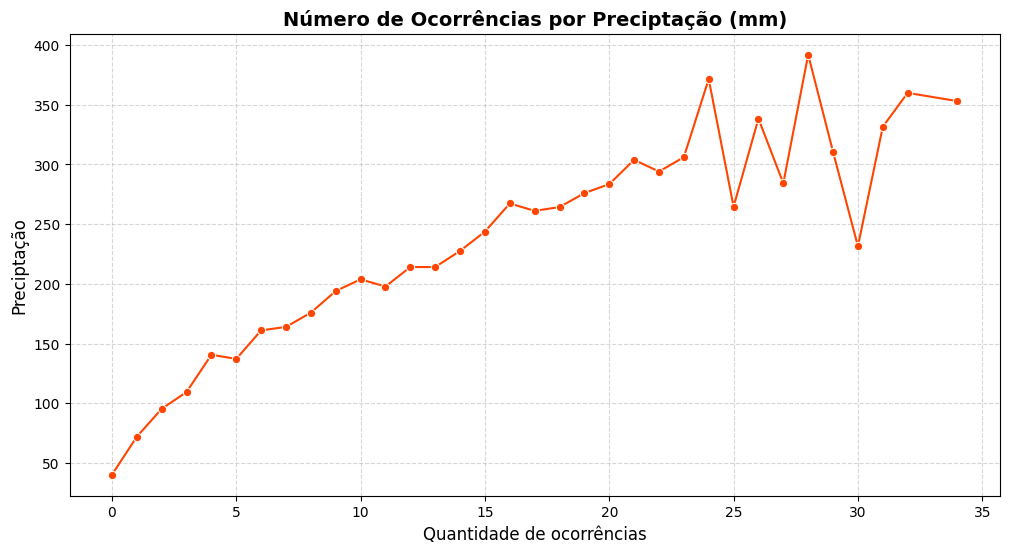

In [29]:

plt.figure(figsize=(12, 6))

sns.lineplot(x='ocorrencias_deslizamento', y='chuva_mm', data=df, marker='o', errorbar=None, color='#FF4500')
plt.title('Número de Ocorrências por Preciptação (mm)', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de ocorrências', fontsize=12)
plt.ylabel('Preciptação', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

## Índice de Letalidade dos Eventos

Nesta etapa foi calculado o índice de letalidade, obtido pela razão entre o número de óbitos e a quantidade de ocorrências registradas em cada município.

O indicador busca identificar localidades onde os eventos apresentaram maior impacto humano proporcionalmente ao número de ocorrências.

Municípios com índices mais elevados podem demandar maior atenção em ações de prevenção, evacuação e conscientização da população.

In [30]:
# Analisando o Índice de Letalidade (Óbitos por Ocorrência)
df_letalidade = df.groupby('municipio')[['ocorrencias_deslizamento', 'obitos']].sum()
df_letalidade['letalidade_por_evento'] = df_letalidade['obitos'] / df_letalidade['ocorrencias_deslizamento']
df_letalidade = df_letalidade.sort_values(by='letalidade_por_evento', ascending=False)

print("Cidades com maior letalidade por evento:")
display(df_letalidade.head(5))

Cidades com maior letalidade por evento:


,ocorrencias_deslizamento,obitos,letalidade_por_evento
municipio,,,
Nova Friburgo,927,52,0.056095
Rio de Janeiro,399,21,0.052632
Petrópolis,1085,56,0.051613
Teresópolis,1102,55,0.049909
Nova Iguaçu,444,22,0.049550


## Volume de Chuva Associado ao Risco Crítico

Esta análise identifica o menor volume de precipitação registrado em situações classificadas com nível de risco "Crítico".

O resultado fornece uma referência para compreender em quais condições de chuva os cenários mais severos começam a ocorrer dentro da base analisada.

Esse tipo de informação pode servir como apoio para estudos de monitoramento e definição de parâmetros de alerta.

In [31]:
# Qual o volume médio de chuva que dispara o nível 'Crítico'?
limiar_critico = df[df['nivel_risco'] == 'Crítico']['chuva_mm'].min()
print(f"O nível de risco Crítico começa a ser registrado a partir de {limiar_critico:.2f} mm de chuva.")

O nível de risco Crítico começa a ser registrado a partir de 61.30 mm de chuva.


## Distribuição de Deslizamentos por Região e Mês

O mapa de calor apresenta a concentração de ocorrências de deslizamentos considerando simultaneamente as regiões do estado e os meses do ano.

Quanto mais intensa a coloração, maior o número de ocorrências registradas naquele período e localidade.

A visualização facilita a identificação de regiões mais afetadas e dos períodos de maior incidência dos eventos.

In [32]:
# Agrupando por região e mês
heatmap_data = df.pivot_table(index='regiao_rj', columns='mes', values='ocorrencias_deslizamento', aggfunc='sum')

# Isso gera uma tabela pronta para um mapa de calor
display(heatmap_data)

mes,1,2,3,4,5,6,7,8,9,10,11,12
regiao_rj,,,,,,,,,,,,
Baixada,72,58,58,18,35,39,16,25,16,26,18,63
Costa Verde,73,80,55,17,14,28,26,17,18,31,41,85
Metropolitana,123,129,157,38,73,44,37,40,45,47,45,113
Norte Fluminense,61,65,83,18,50,16,24,12,23,29,31,80
Serrana,474,418,473,168,149,179,137,184,167,149,164,452


In [33]:

fig = px.imshow(heatmap_data, title="Mapa de Calor: Ocorrências por Região e Mês")
fig.show()

## Modelo de Classificação de Nível de Risco

A árvore de decisão foi construída utilizando variáveis relacionadas às condições ambientais e geográficas para prever o nível de risco associado aos eventos.

O modelo demonstra como diferentes fatores, como volume de chuva, índice do solo e município, influenciam a classificação dos níveis de risco.

Além de auxiliar na interpretação dos dados, a técnica permite compreender quais variáveis possuem maior influência no processo de tomada de decisão do modelo.

[Text(0.5, 0.875, 'chuva_mm <= 132.75\ngini = 0.713\nsamples = 960\nvalue = [245.0, 117.0, 376.0, 222.0]\nclass = Crítico'),
 Text(0.25, 0.625, 'chuva_mm <= 70.1\ngini = 0.704\nsamples = 508\nvalue = [144, 117, 48, 199]\nclass = Médio'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'chuva_mm <= 32.25\ngini = 0.563\nsamples = 198\nvalue = [12, 97, 2, 87]\nclass = Baixo'),
 Text(0.0625, 0.125, 'gini = 0.332\nsamples = 73\nvalue = [1, 58, 0, 14]\nclass = Baixo'),
 Text(0.1875, 0.125, 'gini = 0.554\nsamples = 125\nvalue = [11, 39, 2, 73]\nclass = Médio'),
 Text(0.375, 0.375, 'chuva_mm <= 101.4\ngini = 0.662\nsamples = 310\nvalue = [132, 20, 46, 112]\nclass = Alto'),
 Text(0.3125, 0.125, 'gini = 0.607\nsamples = 156\nvalue = [54, 12, 10, 80]\nclass = Médio'),
 Text(0.4375, 0.125, 'gini = 0.643\nsamples = 154\nvalue = [78.0, 8.0, 36.0, 32.0]\nclass = Alto'),
 Text(0.75, 0.625, 'chuva_mm <= 177.85\ngini = 0.421\nsamples = 452\nvalue = [101, 0, 328, 23]\nclass = Crítico'),
 Text(0.625, 0.

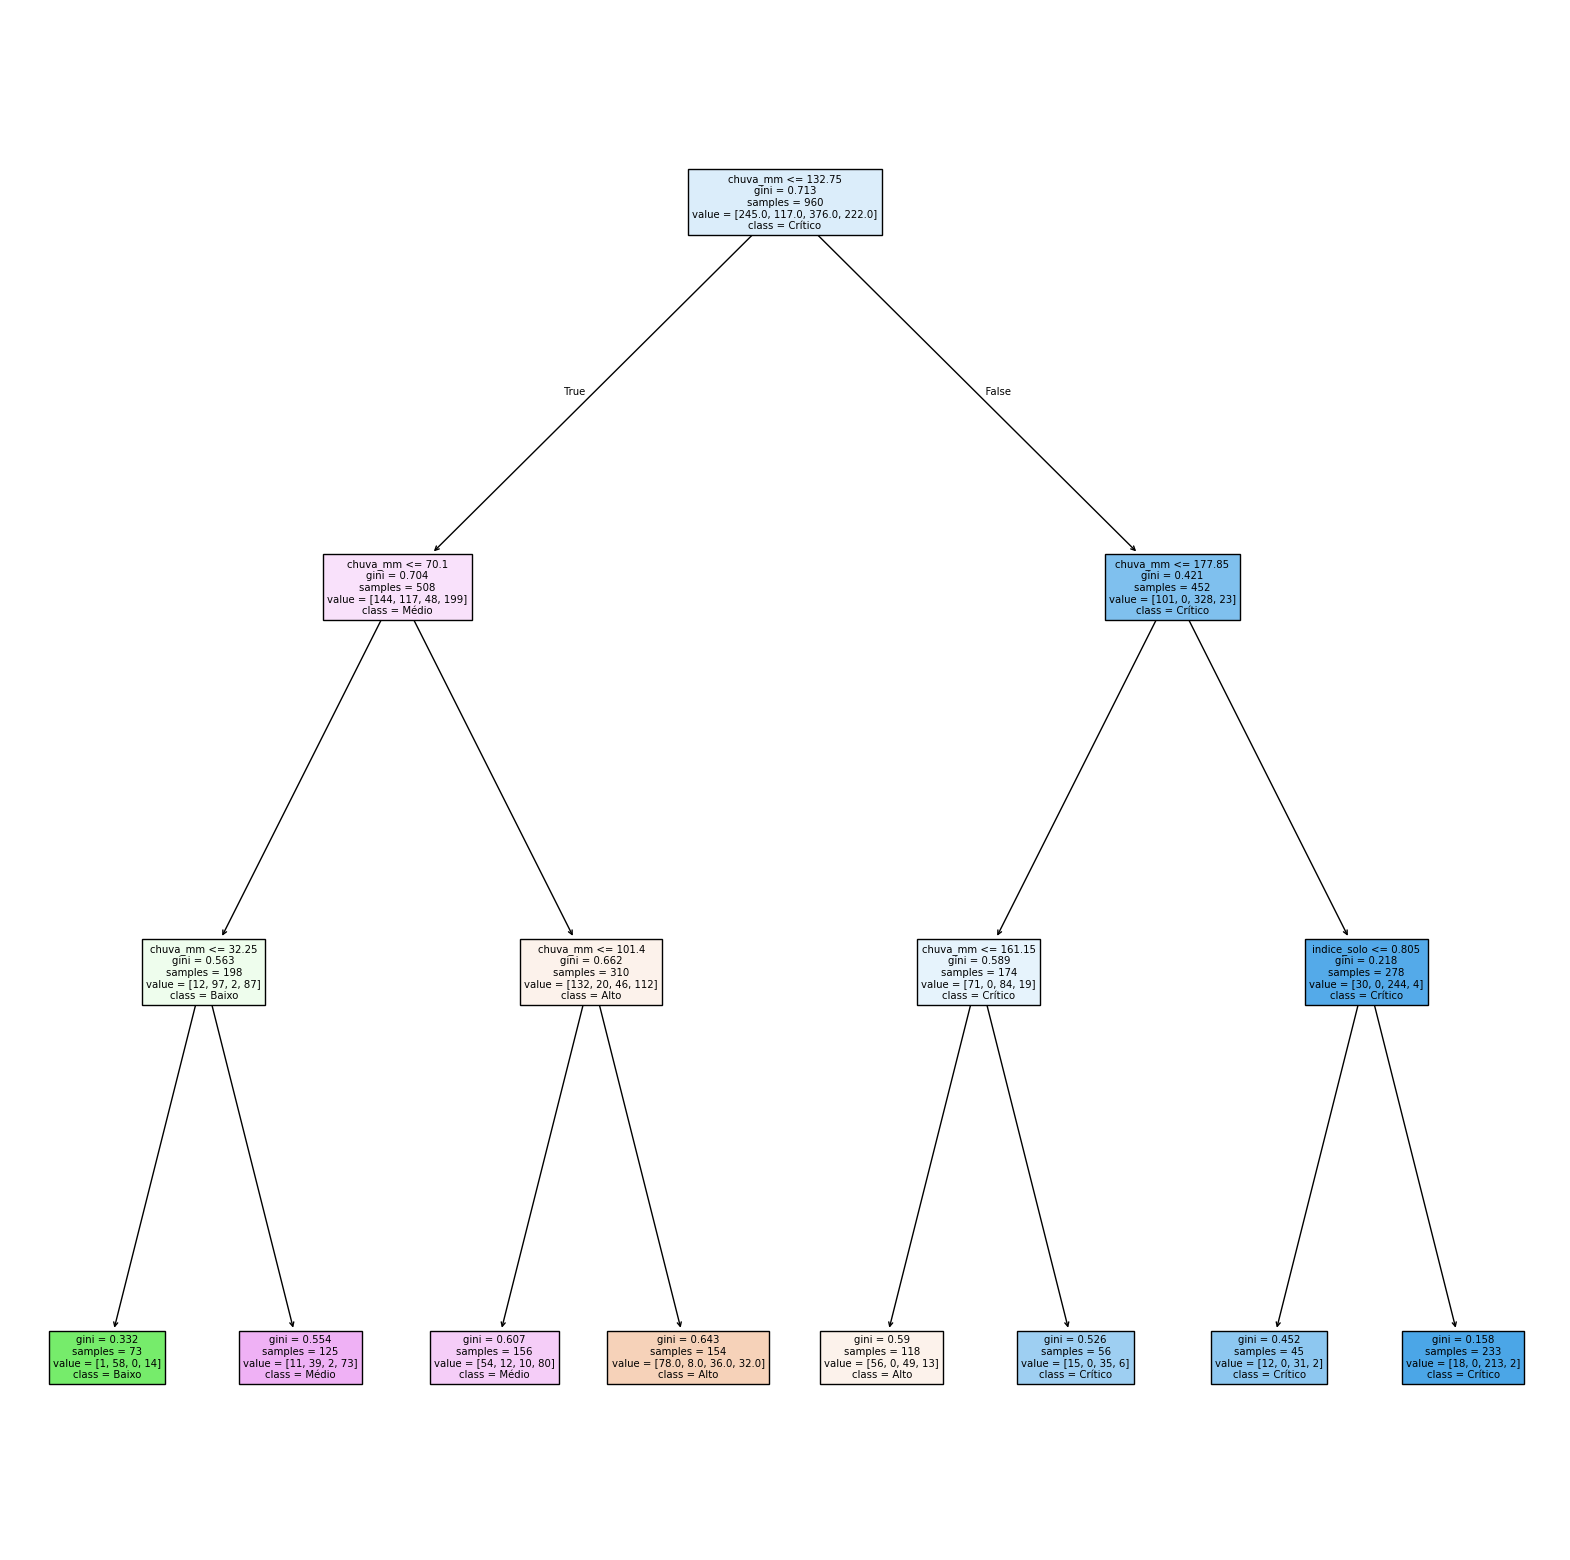

In [34]:
from sklearn import tree
import matplotlib.pyplot as plt

features = ['chuva_mm', 'indice_solo', 'municipio',]
target = 'nivel_risco'

X = df[features]
y = df[target]

X = X.replace({
    "Rio de Janeiro": 0, "Niterói": 1, "Teresópolis": 2, "Petrópolis": 3, "Angra dos Reis": 4, "Campos dos Goytacazes": 5, "Nova Iguaçu": 6, "Nova Friburgo": 7,
    "Baixo": 0, "Médio": 1, "Alto": 2, "Crítico": 3
})

model = tree.DecisionTreeClassifier(max_depth=3, min_samples_split=20)
model.fit(X=X, y=y)


# %%
plt.figure(figsize=[20, 20], dpi=100)
tree.plot_tree(model, feature_names=features, class_names=model.classes_, filled=True)


## Intensidade de Deslizamentos por Município ao Longo dos Anos

Este gráfico apresenta a distribuição dos deslizamentos registrados em cada município ao longo do período analisado.

O tamanho e a intensidade das marcações representam a quantidade total de ocorrências observadas.

A visualização permite identificar municípios com maior recorrência de eventos e analisar sua evolução temporal.

In [35]:
escala_coral_vermelho = ['#FF7F50', '#FF4500', '#B22222', '#8B0000']
df_anual = df.groupby(['ano', 'municipio'])[['ocorrencias_deslizamento']].sum().reset_index()
# 2. Criar o gráfico com a escala personalizada
fig = px.scatter(
    df_anual, 
    x='ano', 
    y='municipio', 
    size='ocorrencias_deslizamento',       
    color='ocorrencias_deslizamento',      
    color_continuous_scale=escala_coral_vermelho, # Aplica a paleta definida
    title="Intensidade de Deslizamentos por Município",
    labels={'ocorrencias_deslizamento': 'Total de Deslizamentos', 'ano': 'Ano', 'municipio': 'Município'}
)

# 3. Ajustes finos para a apresentação
fig.update_layout(
    template="plotly_white",
    height=800,
    coloraxis_colorbar=dict(title="Nível de Deslizamentos")
)



## Intensidade de Óbitos por Município ao Longo dos Anos

Este gráfico apresenta a distribuição dos óbitos associados aos deslizamentos em cada município ao longo do período analisado.

O tamanho das marcações representa a quantidade de mortes registradas, enquanto a intensidade da cor reforça a magnitude do impacto.

A análise permite identificar localidades que apresentaram maior vulnerabilidade em termos de perdas humanas.

In [36]:
escala_coral_vermelho = ['#FF7F50', '#FF4500', '#B22222', '#8B0000']
df_anual = df.groupby(['ano', 'municipio'])[['obitos']].sum().reset_index()
# 2. Criar o gráfico com a escala personalizada
fig = px.scatter(
    df_anual, 
    x='ano', 
    y='municipio', 
    size='obitos',       
    color='obitos',      
    color_continuous_scale=escala_coral_vermelho, # Aplica a paleta definida
    title="Intensidade de Óbitos por Município",
    labels={'obitos': 'Total de Óbitos', 'ano': 'Ano', 'municipio': 'Município'}
)

# 3. Ajustes finos para a apresentação
fig.update_layout(
    template="plotly_white",
    height=800,
    coloraxis_colorbar=dict(title="Nível de Óbitos")
)


## Evolução Temporal dos Óbitos

Este gráfico mostra a evolução anual do número total de óbitos registrados na base de dados.

A análise permite observar tendências de crescimento, redução ou estabilidade ao longo do período estudado.

O acompanhamento desse indicador é importante para avaliar o impacto humano dos eventos e a efetividade de medidas de prevenção e resposta.

In [37]:
df['data'] = pd.to_datetime(df['data'], errors='coerce', dayfirst=True)
df_anual = df.groupby('ano')[['obitos']].sum().reset_index()

fig = px.line(
    df_anual,
    x='ano',
    y='obitos',
    markers=True, 
    title="Evolução Temporal de Óbitos (Total do Estado)",
    labels={'obitos': 'Total de Óbitos', 'ano': 'Ano'}
)

fig.update_traces(line_color='#FF4500', line_width=3)
fig.update_layout(
    template="plotly_white",
    hovermode="x unified" # 'x unified' deixa a dica de ferramenta muito mais limpa
)

## Evolução Temporal dos Desalojados

Este gráfico apresenta a evolução anual da quantidade de pessoas desalojadas em decorrência dos eventos registrados.

O indicador reflete o impacto social causado pelos deslizamentos e auxilia na compreensão das consequências enfrentadas pela população afetada.

A análise temporal permite identificar períodos com maior necessidade de assistência e suporte emergencial.

In [38]:

df_anual = df.groupby('ano')[['desalojados']].sum().reset_index()

fig = px.line(
    df_anual,
    x='ano',
    y='desalojados',
    markers=True, 
    title="Evolução Temporal de desalojados (Total do Estado)",
    labels={'desalojados': 'Total de desalojados', 'ano': 'Ano'}
)

fig.update_traces(line_color='#FF4500', line_width=3)
fig.update_layout(
    template="plotly_white",
    hovermode="x unified" # 'x unified' deixa a dica de ferramenta muito mais limpa
)

## Evolução Histórica dos Deslizamentos no Município Mais Afetado

Após identificar o município com o maior número acumulado de deslizamentos, foi realizada uma análise específica de sua evolução ao longo dos anos.

O objetivo é compreender como o comportamento das ocorrências se desenvolveu ao longo do período analisado e verificar possíveis tendências de crescimento ou redução.

Essa abordagem permite aprofundar o estudo sobre a localidade mais impactada da base de dados.

In [39]:
cidade_campea = df.groupby('municipio')['ocorrencias_deslizamento'].sum().idxmax()

# Cidade que teve mais deslizamentos
df_campea = df[df['municipio'] == cidade_campea].groupby('ano')[['ocorrencias_deslizamento']].sum().reset_index()


fig = px.line(
    df_campea, 
    x='ano', 
    y='ocorrencias_deslizamento', 
    markers=True, 
    title=f"Evolução Histórica de Deslizamentos: {cidade_campea}",
    labels={'ocorrencias_deslizamento': 'Total de Ocorrências', 'ano': 'Ano'}
)

# 4. Força a exibição dos anos de 2015 a 2024
fig.update_traces(line_color='#FF4500', line_width=3) # Vermelho escuro para destacar o impacto


## Evolução da Precipitação no Município com Maior Acumulado de Chuvas

Após identificar o município que apresentou o maior volume acumulado de precipitação, foi realizada uma análise temporal da evolução das chuvas ao longo dos anos.

O objetivo é verificar o comportamento dos índices pluviométricos e identificar possíveis variações relevantes no período analisado.

A compreensão dessa dinâmica é importante para estudos relacionados à ocorrência de deslizamentos e avaliação de riscos ambientais.

In [40]:
cidade_campea = df.groupby('municipio')['chuva_mm'].sum().idxmax()

# Cidade que teve mais deslizamentos
df_campea = df[df['municipio'] == cidade_campea].groupby('ano')[['chuva_mm']].sum().reset_index()


fig = px.line(
    df_campea, 
    x='ano', 
    y='chuva_mm', 
    markers=True, 
    title=f"Evolução Histórica de Preciptação: {cidade_campea}",
    labels={'chuva_mm': 'Total de Preciptação', 'ano': 'Ano'}
)

# 4. Força a exibição dos anos de 2015 a 2024
fig.update_traces(line_color='#FF4500', line_width=3) # Vermelho escuro para destacar o impacto

## Distribuição dos Deslizamentos por Município em 2015

Este gráfico apresenta o total de ocorrências de deslizamentos registradas em cada município durante o ano de 2015.

A visualização permite comparar o comportamento das diferentes localidades em um período específico, identificando aquelas que apresentaram maior concentração de eventos.

A análise auxilia na compreensão da distribuição espacial dos deslizamentos dentro do estado.

In [41]:
df_2015 = (
    df[df['ano'] == 2015]
    .groupby('municipio', as_index=False)['ocorrencias_deslizamento']
    .sum()
)

fig = px.bar(
    df_2015,
    x='municipio',
    y='ocorrencias_deslizamento',
    title='Deslizamentos por município em 2015',
    labels={
        'municipio': 'Município',
        'ocorrencias_deslizamento': 'Número de Deslizamentos'
    }
)
fig.update_layout(
    width=1600,   # largura da figura
    height=600    # altura da figura
)

fig.update_traces(marker_color='#FF4500')

fig.show()

In [ ]:
from sqlalchemy import create_engine

database_path = r"C:\GeoRisk-RJ\projeto-georisk\database\georisk.db"

engine = create_engine(f"sqlite:///{database_path}")

# 2. A sua Query original
query = """
    SELECT 
        o.municipio, 
        o.ocorrencias_deslizamento,
        o.obitos,
        o.desalojados,
        c.valor_adaptativo,
        c.classe_adaptativa,
        c.valor_per_capita,
        c.classe_per_capita
    FROM ocorrencias o
    JOIN capacidade_adaptativa c ON o.municipio = c.municipio
    WHERE o.ano = 2015
"""

# Executando a leitura
df = pd.read_sql(query, engine)
print("Dados carregados com sucesso! Linhas retornadas:", len(df))

Dados carregados com sucesso! Linhas retornadas: 84


## Municípios com Maior Capacidade Adaptativa 2015

O gráfico apresenta os municípios com os maiores índices de capacidade adaptativa registrados em 2015.

Este indicador representa o nível de preparação institucional, financeira e estrutural dos municípios para enfrentar eventos adversos relacionados ao clima.

Valores mais elevados indicam melhores condições de resposta e adaptação diante de riscos ambientais.

C:\Users\bernardo\AppData\Local\Temp\ipykernel_3540\1860442461.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_preparados, x='valor_adaptativo', y='municipio', palette='crest')


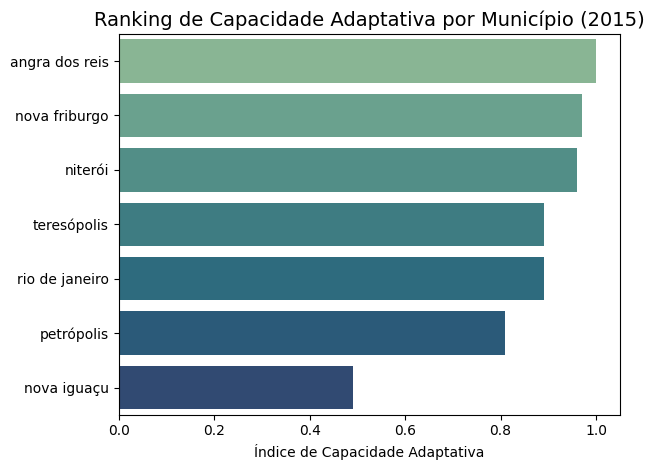

In [45]:
plt.figure()
df_preparados = df.sort_values(by='valor_adaptativo', ascending=False)
sns.barplot(data=df_preparados, x='valor_adaptativo', y='municipio', palette='crest')
plt.title('Ranking de Capacidade Adaptativa por Município (2015)', fontsize=14)
plt.xlabel('Índice de Capacidade Adaptativa')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Distribuição do Investimento Per Capita 2015

O gráfico apresenta como os investimentos em adaptação e proteção ambiental estão distribuídos entre os municípios.

A análise permite identificar se os recursos estão concentrados em poucos municípios ou distribuídos de forma mais equilibrada.

Diferenças significativas podem indicar desigualdades na capacidade de investimento local.

In [124]:
import plotly.express as px

fig = px.scatter(
    df, 
    x='valor_per_capita', 
    y='valor_adaptativo', 
    hover_name='municipio', 
    hover_data={
        'valor_per_capita': ':.2f',
        'valor_adaptativo': ':.2f'
    },
    title='Investimento Per Capita vs. Capacidade Adaptativa',
    labels={
        'valor_per_capita': 'Investimento Per Capita', 
        'valor_adaptativo': 'Valor Adaptativo'
    },
    color_discrete_sequence=['teal'] 
)

fig.update_traces(marker=dict(size=28, line=dict(width=2, color='DarkSlateGrey')))


fig.show()

## Capacidade Adaptativa e Impactos dos Deslizamentos 2015

Esta análise investiga a relação entre a capacidade adaptativa dos municípios e os impactos observados nos eventos de deslizamento.

A hipótese é que municípios com melhores condições de planejamento, investimento e gestão apresentem menor número de vítimas, desalojados ou ocorrências graves.

A comparação permite avaliar a possível influência da capacidade adaptativa na redução da vulnerabilidade socioambiental.

In [125]:
map_color = {
    'Alto': '#2ecc71',   
    'Médio': '#f1c40f',  
    
}

df_consolidado = df.groupby('municipio', as_index=False).agg({
    'ocorrencias_deslizamento': 'sum', # Soma todos os eventos do ano
    'valor_adaptativo': 'first',       # Mantém o índice (pois é igual o ano todo)
    'classe_adaptativa': 'first',
    'classe_per_capita': 'first',
    'valor_per_capita': 'first'
})

fig1 = px.scatter(
    df_consolidado, 
    x='valor_adaptativo', 
    y='ocorrencias_deslizamento', 
    hover_name='municipio', # O mouse revela a cidade
    color='classe_adaptativa', # Colore os pontos pela classificação
    size='valor_per_capita', # O tamanho da bolha mostra quem recebeu mais dinheiro
    title='Correlação: Capacidade Adaptativa vs. Deslizamentos (2015)',
    labels={
        'valor_adaptativo': 'Índice de Capacidade Adaptativa', 
        'ocorrencias_deslizamento': 'Total de Deslizamentos',
        'classe_adaptativa': 'Classe Adaptativa'
    },
    color_discrete_map=map_color
)

# Adiciona uma borda escura nas bolhas para não sumirem no fundo branco
fig1.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
fig1.show()

In [126]:
map_color = {
    'Alto': '#2ecc71',   
    'Médio': '#f1c40f',  
    
}

fig2 = px.scatter(
    df_consolidado, 
    x='valor_per_capita', 
    y='ocorrencias_deslizamento', 
    hover_name='municipio',
    color='classe_per_capita', 
    size='valor_per_capita', 
    title='Correlação: Investimento Per Capita vs. Total de Deslizamentos (2015)',
    labels={
        'valor_per_capita': 'Índice de Investimento Per Capita', 
        'ocorrencias_deslizamento': 'Total de Deslizamentos',
        'classe_per_capita': 'Classe de Investimento Per Capita'
    },
    color_discrete_map=map_color
)

fig2.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
fig2.show()